# Topic 2 — Predictive Modelling
### Modelling strategy

| RQ | Unit of analysis | Target | Metric | Why |
|----|-----------------|--------|--------|-----|
| **RQ1** | Individual cyclable trip (~14 600) | `is_bike` (0/1) | AUC-ROC | High N, binary, avoids aggregation bias |
| **RQ2** | Individual trip by elderly 65+ in Eindhoven (~1 200) | `is_car` (0/1) | AUC-ROC | Avoids pseudo-replication of buurt-level regression; class imbalance handled with `balanced` weights |

Three models per RQ: **Logistic Regression** (interpretable baseline) → **Random Forest** → **XGBoost**.  
SHAP values are used to identify which features drive each prediction, directly answering both RQs.


## 0. Imports & Paths

In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import shap

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost available ✓")
except ImportError:
    HAS_XGB = False
    print("XGBoost not found — using sklearn GradientBoostingClassifier")

HERE  = Path.cwd()
T1OUT = HERE / "output"
DATA  = HERE / "data"
OUT   = HERE / "output_topic2"
MODEL_OUT = OUT / "models"
OUT.mkdir(exist_ok=True)
MODEL_OUT.mkdir(exist_ok=True)

ODIN_PATH = DATA / "odin2024_full.csv"
KWB_PATH  = DATA / "kwb2025.xlsx"

plt.rcParams.update({"figure.dpi": 150, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
PALETTE   = ["#2d6a4f", "#40916c", "#74c69d", "#b7e4c7"]
TYPE_COL  = {
    "High-density urban neighbourhood"             : "#1f77b4",
    "Low-density family / VINEX-like neighbourhood": "#ff7f0e",
    "Other neighbourhood"                          : "#aec7e8",
    "High-density urban gemeente"                  : "#1f77b4",
    "VINEX-like gemeente"                          : "#ff7f0e",
    "Mixed gemeente"                               : "#d3d3d3",
}
TYPE_ENC  = {"High-density urban gemeente": 2, "VINEX-like gemeente": 0, "Mixed gemeente": 1}
LIFE_ORDER = ["Child/Teen (<18)", "Young Adult (18-29)", "Family w/ Kids",
               "Mid-life No Kids (30-54)", "Older Adult (55-69)", "Senior (70+)"]
MODEL_NAME = "XGBoost" if HAS_XGB else "GBM (sklearn)"
EINDHOVEN_CODES = [743,753,762,770,772,794,820,823,847,848,858,861,866,
                   1652,1658,1659,1667,1706,1724,1728,1771]
print("✓ Setup complete")


XGBoost available ✓
✓ Setup complete


## 1. Load Topic 1 Outputs

All datasets were produced by the Topic 1 pipeline and are loaded here directly.

| File | Content | Used for |
|------|---------|----------|
| `05_accessibility_context_buurten.csv` | Buurt-level accessibility + neighbourhood_type | RQ2 context |
| `03b_brabant_cyclable_trips_with_access.csv` | Trip-level ODiN trips with gemeente access scores | **RQ1 & RQ2 main dataset** |


In [32]:
access    = pd.read_csv(T1OUT / "05_accessibility_context_buurten.csv")
trips_cyc = pd.read_csv(T1OUT / "03b_brabant_cyclable_trips_with_access.csv")

# Coerce numeric trip columns
for col in ["KHvm", "KAfstV", "KLeeft", "KMotiefV", "Wogem_DANS24", "weight_v"]:
    if col in trips_cyc.columns:
        trips_cyc[col] = pd.to_numeric(
            trips_cyc[col].astype(str).replace("#NULL!", np.nan), errors="coerce"
        )

print(f"access (buurten)       : {access.shape}")
print(f"trips_cyc (trip-level) : {trips_cyc.shape}")
print(f"\nTrips by mode (KHvm):")
print(trips_cyc["KHvm"].value_counts().head(6).to_string())
print(f"\nLife stage distribution:")
print(trips_cyc["life_stage"].value_counts().to_string())


access (buurten)       : (14729, 37)
trips_cyc (trip-level) : (14637, 31)

Trips by mode (KHvm):
KHvm
5.0    4773
6.0    4244
1.0    4001
2.0    1195
7.0     327
4.0      97

Life stage distribution:
life_stage
Older Adult (55-69)         3273
Family w/ Kids              3269
Senior (70+)                2431
Child/Teen (<18)            1943
Young Adult (18-29)         1931
Mid-life No Kids (30-54)    1790


## 2. Feature Enrichment from Raw Sources

Topic 1's `weighted_aggregation()` computes mode shares and access scores but not car availability,
habitual frequencies, or physical distances. We derive these features here from the **same raw files
already used in Topic 1** — no new data sources are introduced.

| Feature | Source file | Variable | Justification |
|---------|------------|---------|---------------|
| `pct_has_car` | ODiN `OPAuto_DANS24` | Car on respondent's name | Primary car access proxy |
| `pct_has_license` | ODiN `OPRijbewijsAu` | Driving licence | Physical ability to drive |
| `pct_has_ebike` | ODiN `HHEFiets_DANS24` | E-bike in household | Active mode availability |
| `habit_bike_freq` | ODiN `FqNEFiets` | Cycling freq (1=daily, 6=never) | Cultural/habitual cycling norm |
| `habit_car_freq` | ODiN `FqAutoB` | Car freq (1=daily, 6=never) | Car dependency proxy |
| `pct_cycling_season` | ODiN `Maand` | Apr–Sep trips | Seasonal correction |
| `pct_weekend` | ODiN `Dag` | Weekend trips | Trip purpose correction |
| `avg_dist_gp_km` | KWB `g_afs_hp` | Distance to GP (km) | Utilitarian accessibility |
| `avg_dist_super_km` | KWB `g_afs_kv` | Distance to supermarket (km) | Utilitarian accessibility |
| `pct_single_family` | KWB `p_1gezw` | % single-family homes | VINEX morphology proxy |


In [33]:
# ── 2a. KWB: population-weighted municipality aggregates ─────────────────────
def to_number(s):
    return (s.astype(str).str.replace(",", ".", regex=False)
             .replace({"." : np.nan, "nan": np.nan})
             .pipe(pd.to_numeric, errors="coerce"))

kwb_raw = pd.read_excel(KWB_PATH, sheet_name="KWB2025", dtype=str)
kwb_brt = kwb_raw[kwb_raw["recs"] == "Buurt"].copy()
for c in ["a_inw", "p_1gezw", "g_afs_hp", "g_afs_kv", "ste_oad"]:
    kwb_brt[c] = to_number(kwb_brt[c])
kwb_brt["Wogem_DANS24"] = pd.to_numeric(
    kwb_brt["gwb_code_8"].str[:4], errors="coerce"
).astype("Int64")

def pop_w(grp, col):
    v = grp[[col, "a_inw"]].dropna()
    return np.nan if v.empty or v["a_inw"].sum() == 0 else np.average(v[col], weights=v["a_inw"])

kwb_muni_agg = (
    kwb_brt.groupby("Wogem_DANS24")
    .apply(lambda g: pd.Series({
        "avg_dist_gp_km"   : pop_w(g, "g_afs_hp"),
        "avg_dist_super_km": pop_w(g, "g_afs_kv"),
        "pct_single_family": pop_w(g, "p_1gezw"),
        "avg_sted"         : pop_w(g, "ste_oad"),
    }), include_groups=False)
    .reset_index()
)
print(f"KWB municipality aggregates: {kwb_muni_agg.shape}")
print(kwb_muni_agg.describe().round(2).to_string())


KWB municipality aggregates: (342, 5)
       Wogem_DANS24  avg_dist_gp_km  avg_dist_super_km  pct_single_family  avg_sted
count         342.0          342.00             342.00             342.00    342.00
mean         823.85            1.24               0.79              77.37   1199.26
std          629.64            0.41               0.22              12.59    784.46
min            14.0            0.47               0.39              15.18    220.01
25%           310.5            0.92               0.63              71.76    636.46
50%           626.5            1.15               0.76              81.14    998.59
75%          1567.0            1.49               0.92              86.12   1588.18
max          1992.0            2.71               1.64              98.00   5805.87


In [34]:
# ── 2b. ODiN 2024: read with correct separator and column names ───────────────
ODIN_COLS_NEEDED = [
    "Wogem_DANS24", "Prov", "KLeeft",
    "FactorV",
    "OPAuto_DANS24",    # → HvAuto
    "OPRijbewijsAu",    # → HvRijbewijs
    "HHEFiets_DANS24",  # → HvEFiets
    "FqNEFiets", "FqAutoB", "Dag", "Maand",
]

def safe_read_odin(path, cols, sep=","):
    df = pd.read_csv(path, sep=sep)
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"  [INFO] not in {Path(path).name}: {missing}")
    return df[[c for c in cols if c in df.columns]]

odin24 = safe_read_odin(ODIN_PATH, ODIN_COLS_NEEDED, sep=";")

# Rename to canonical names
odin24 = odin24.rename(columns={
    "OPAuto_DANS24"   : "HvAuto",
    "OPRijbewijsAu"   : "HvRijbewijs",
    "HHEFiets_DANS24" : "HvEFiets",
})

# Coerce numeric — all except FactorV
for col in ["Wogem_DANS24", "Prov", "KLeeft",
            "HvAuto", "HvRijbewijs", "HvEFiets",
            "FqNEFiets", "FqAutoB", "Dag", "Maand"]:
    if col in odin24.columns:
        odin24[col] = pd.to_numeric(
            odin24[col].astype(str).replace("#NULL!", np.nan), errors="coerce"
        )

# FactorV: "67.274.247.413" format → remove all dots → divide by 1000
odin24["FactorV"] = (
    odin24["FactorV"].astype(str)
    .str.replace(".", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
    .div(1e3)
)

print(f"ODiN 2024 loaded       : {odin24.shape}")
print(f"FactorV median         : {odin24['FactorV'].median():.0f}")
print(f"Brabant trips (Prov=11): {(odin24['Prov']==11).sum()}")


ODiN 2024 loaded       : (9784, 11)
FactorV median         : 78072701
Brabant trips (Prov=11): 1227


In [35]:
# ── 2c. Derive behavioural features per municipality (Brabant only) ───────────
brabant24 = odin24[odin24["Prov"] == 11].copy()

# Normalise trip weights
raw_w = brabant24["FactorV"]
brabant24["weight_v"] = raw_w / raw_w.sum() * len(raw_w)

def feat_per_muni(df, grp_col="Wogem_DANS24"):
    rows = []
    for muni, g in df.groupby(grp_col):
        w    = g["weight_v"]
        wsum = w.sum()
        if pd.isna(wsum) or wsum == 0:
            continue
        row = {"Wogem_DANS24": muni}
        for col, key in [("HvAuto",    "pct_has_car"),
                         ("HvRijbewijs","pct_has_license"),
                         ("HvEFiets",  "pct_has_ebike")]:
            if col in g.columns:
                row[key] = ((g[col] == 1) * w).sum() / wsum
        for col, key in [("FqNEFiets", "habit_bike_freq"),
                         ("FqAutoB",   "habit_car_freq")]:
            if col in g.columns:
                valid = g[col].notna()
                if valid.sum() > 0:
                    row[key] = (g.loc[valid, col] * w[valid]).sum() / w[valid].sum()
        if "Maand" in g.columns:
            row["pct_cycling_season"] = (g["Maand"].between(4, 9) * w).sum() / wsum
        if "Dag" in g.columns:
            row["pct_weekend"] = (g["Dag"].isin([6, 7]) * w).sum() / wsum
        rows.append(row)
    return pd.DataFrame(rows)

odin_behav = feat_per_muni(brabant24)
print(f"Behavioural features per gemeente: {odin_behav.shape}")
print(f"Features: {[c for c in odin_behav.columns if c != 'Wogem_DANS24']}")
print()
print(odin_behav.describe().round(3).to_string())


Behavioural features per gemeente: (49, 8)
Features: ['pct_has_car', 'pct_has_license', 'pct_has_ebike', 'habit_bike_freq', 'habit_car_freq', 'pct_cycling_season', 'pct_weekend']

       Wogem_DANS24  pct_has_car  pct_has_license  pct_has_ebike  habit_bike_freq  habit_car_freq  pct_cycling_season  pct_weekend
count        49.000       49.000           49.000         49.000           49.000          49.000              49.000       49.000
mean       1287.571        0.553            0.824          0.497            3.448           2.255               0.548        0.050
std        1215.760        0.346            0.276          0.343            1.024           1.131               0.350        0.156
min         743.000        0.000            0.000          0.000            1.000           1.000               0.000        0.000
25%         785.000        0.283            0.767          0.190            2.938           1.550               0.277        0.000
50%         847.000        0.606  

## 3. Feature Engineering

### 3a. RQ1 — Trip-level feature matrix

**Target:** `is_bike` — 1 if the cyclable trip was made by bicycle, 0 otherwise.

**Feature tiers:**
- **Tier 1 (hypothesis-core):** `pop_weighted_*_access`, `type_code` — directly tests RQ1
- **Tier 2 (individual context):** `KAfstV` (trip distance), `life_stage_code` — strongest behavioural predictors
- **Tier 3 (municipality confounders):** car availability, habitual frequencies, physical distances


In [36]:
# ── Build RQ1 trip-level feature matrix ──────────────────────────────────────
rq1 = trips_cyc.copy()

# Binary target
rq1["is_bike"] = (rq1["KHvm"] == 5).astype(int)

# Neighbourhood type encoding
rq1["type_code"] = rq1["dominant_type"].map(TYPE_ENC)

# Life-stage ordinal + one-hot dummies
rq1["life_stage_code"] = rq1["life_stage"].map({ls: i for i, ls in enumerate(LIFE_ORDER)})
ls_dummies = pd.get_dummies(rq1["life_stage"], prefix="ls", drop_first=True)
rq1 = pd.concat([rq1, ls_dummies], axis=1)
LS_COLS = [c for c in rq1.columns if c.startswith("ls_")]

# Merge enriched features (municipality-level)
rq1 = rq1.merge(kwb_muni_agg, on="Wogem_DANS24", how="left")
rq1 = rq1.merge(odin_behav,   on="Wogem_DANS24", how="left")

FEAT_COLS_RQ1 = [f for f in [
    # Tier 1: core hypothesis
    "pop_weighted_total_access",
    "pop_weighted_utilitarian_access",
    "pop_weighted_leisure_social_access",
    "type_code",
    "avg_sted",
    # Tier 2: individual context
    "KAfstV",
    "life_stage_code",
    # Tier 3: municipality confounders
    "pct_has_car",
    "pct_has_license",
    "pct_has_ebike",
    "habit_bike_freq",
    "habit_car_freq",
    "avg_dist_gp_km",
    "avg_dist_super_km",
    "pct_single_family",
    "pct_cycling_season",
    "pct_weekend",
] if f in rq1.columns] + LS_COLS

rq1_model = rq1.dropna(subset=["is_bike"]).reset_index(drop=True)
X1 = rq1_model[FEAT_COLS_RQ1].astype(float)
y1 = rq1_model["is_bike"]

imp1   = SimpleImputer(strategy="median")
X1_imp = pd.DataFrame(imp1.fit_transform(X1), columns=FEAT_COLS_RQ1)

print(f"RQ1 feature matrix: {len(X1_imp):,} trips × {len(FEAT_COLS_RQ1)} features")
print(f"Target: {y1.sum():,} bike ({y1.mean():.1%})  |  {(1-y1).sum():,} other ({(1-y1).mean():.1%})")
print()
missing = X1.isna().sum()
if missing.sum() > 0:
    print("Missing values per feature (filled by median imputer):")
    print(missing[missing > 0].to_string())
else:
    print("Missing values: none")


RQ1 feature matrix: 14,637 trips × 22 features
Target: 4,773 bike (32.6%)  |  9,864 other (67.4%)

Missing values per feature (filled by median imputer):
pop_weighted_total_access               2
pop_weighted_utilitarian_access         2
pop_weighted_leisure_social_access      2
type_code                               2
avg_sted                                2
pct_has_car                           766
pct_has_license                       766
pct_has_ebike                         766
habit_bike_freq                       766
habit_car_freq                        766
avg_dist_gp_km                          2
avg_dist_super_km                       2
pct_single_family                       2
pct_cycling_season                    766
pct_weekend                           766


In [37]:
# ── Feature correlation with target (quick diagnostic) ───────────────────────
corr = (X1_imp.assign(is_bike=y1.values)
        .corr()["is_bike"]
        .drop("is_bike")
        .sort_values(key=abs, ascending=False))

print("Top 10 features correlated with is_bike:")
print(corr.round(3).head(10).to_string())
print()
print("Note: KAfstV expected to be top (shorter distance → more biking)")
print("      life_stage_code expected second (elderly bike less)")


Top 10 features correlated with is_bike:
life_stage_code                      -0.112
ls_Mid-life No Kids (30-54)          -0.085
ls_Family w/ Kids                    -0.067
avg_sted                              0.037
pop_weighted_leisure_social_access    0.036
pop_weighted_total_access             0.034
pop_weighted_utilitarian_access       0.033
KAfstV                               -0.033
pct_single_family                    -0.032
habit_bike_freq                      -0.032

Note: KAfstV expected to be top (shorter distance → more biking)
      life_stage_code expected second (elderly bike less)


### 3b. RQ2 — Trip-level feature matrix (elderly, Eindhoven region)

**Target:** `is_car` — 1 if the elderly (65+) trip was made by car, 0 otherwise.

**Class imbalance:** only 5.8% of elderly trips are by car. All models use `class_weight='balanced'`
(or `scale_pos_weight` for XGBoost) to prevent the majority-class collapse problem.


In [38]:
# ── Build RQ2 trip-level feature matrix (elderly 65+, Eindhoven region) ───────
ELDERLY_KLEEFT = [15, 16, 17, 18]   # ODiN age codes for 65+

trips_elderly = trips_cyc[
    (trips_cyc["KLeeft"].isin(ELDERLY_KLEEFT)) &
    (trips_cyc["Wogem_DANS24"].isin(EINDHOVEN_CODES))
].copy()

# Binary target
trips_elderly["is_car"] = (trips_elderly["KHvm"] == 2).astype(int)

# Neighbourhood type encoding
trips_elderly["type_code"] = trips_elderly["dominant_type"].map(TYPE_ENC)

# Merge enriched features
trips_elderly = trips_elderly.merge(kwb_muni_agg, on="Wogem_DANS24", how="left")
trips_elderly = trips_elderly.merge(odin_behav,   on="Wogem_DANS24", how="left")

FEAT_COLS_RQ2 = [f for f in [
    # Tier 1: core hypothesis (leisure vs utilitarian)
    "pop_weighted_utilitarian_access",
    "pop_weighted_leisure_social_access",
    "pop_weighted_total_access",
    # Tier 2: trip and individual context
    "KAfstV",
    "type_code",
    "avg_sted",
    # Tier 3: confounders
    "pct_has_car",
    "pct_has_license",
    "habit_car_freq",
    "habit_bike_freq",
    "avg_dist_gp_km",
    "avg_dist_super_km",
    "pct_single_family",
] if f in trips_elderly.columns]

rq2_model = trips_elderly.dropna(subset=["is_car"]).reset_index(drop=True)
X2 = rq2_model[FEAT_COLS_RQ2].astype(float)
y2 = rq2_model["is_car"]

imp2   = SimpleImputer(strategy="median")
X2_imp = pd.DataFrame(imp2.fit_transform(X2), columns=FEAT_COLS_RQ2)

neg, pos = (y2 == 0).sum(), (y2 == 1).sum()
print(f"RQ2 feature matrix : {len(X2_imp):,} trips × {len(FEAT_COLS_RQ2)} features")
print(f"Target             : {pos} car trips ({y2.mean():.1%})  |  {neg} other ({(1-y2).mean():.1%})")
print(f"Municipalities     : {rq2_model['Wogem_DANS24'].nunique()}")
print(f"scale_pos_weight   : {neg/pos:.1f}  (used for XGBoost)")
missing2 = X2.isna().sum()
print(f"\nMissing values: {'none' if missing2.sum()==0 else missing2[missing2>0].to_string()}")


RQ2 feature matrix : 1,198 trips × 13 features
Target             : 70 car trips (5.8%)  |  1128 other (94.2%)
Municipalities     : 21
scale_pos_weight   : 16.1  (used for XGBoost)

Missing values: pct_has_car        84
pct_has_license    84
habit_car_freq     84
habit_bike_freq    84


## 4. Exploratory Data Analysis

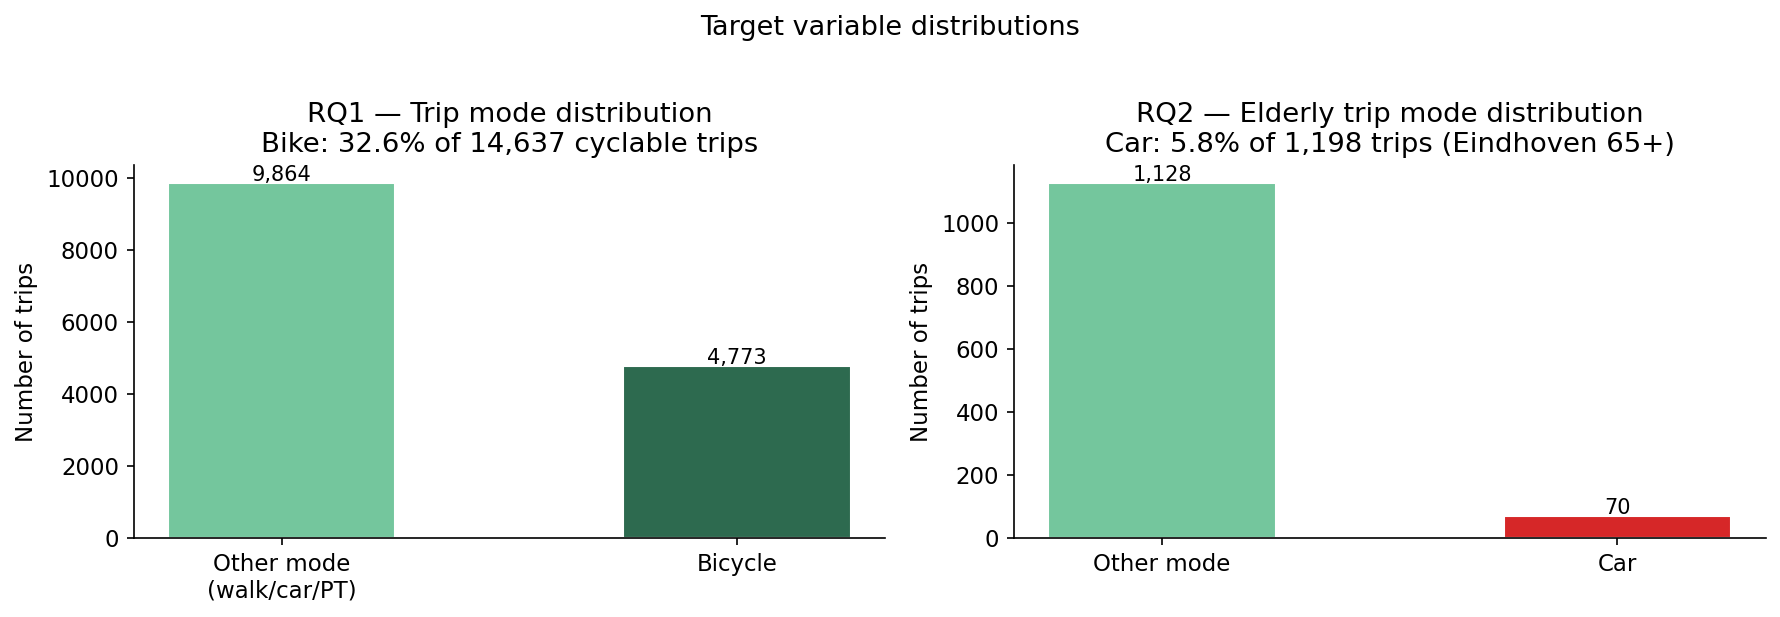

In [39]:
# ── 4a. Target distributions ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Other mode\n(walk/car/PT)", "Bicycle"],
            [y1.value_counts()[0], y1.value_counts()[1]],
            color=[PALETTE[2], PALETTE[0]], edgecolor="white", width=0.5)
axes[0].set_title(f"RQ1 — Trip mode distribution\n"
                  f"Bike: {y1.mean():.1%} of {len(y1):,} cyclable trips")
axes[0].set_ylabel("Number of trips")
for i, v in enumerate([y1.value_counts()[0], y1.value_counts()[1]]):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=10)

axes[1].bar(["Other mode", "Car"],
            [(y2 == 0).sum(), (y2 == 1).sum()],
            color=[PALETTE[2], "#d62728"], edgecolor="white", width=0.5)
axes[1].set_title(f"RQ2 — Elderly trip mode distribution\n"
                  f"Car: {y2.mean():.1%} of {len(y2):,} trips (Eindhoven 65+)")
axes[1].set_ylabel("Number of trips")
for i, v in enumerate([(y2 == 0).sum(), (y2 == 1).sum()]):
    axes[1].text(i, v + 5, f"{v:,}", ha="center", fontsize=10)

plt.suptitle("Target variable distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "fig_t2_00_target_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


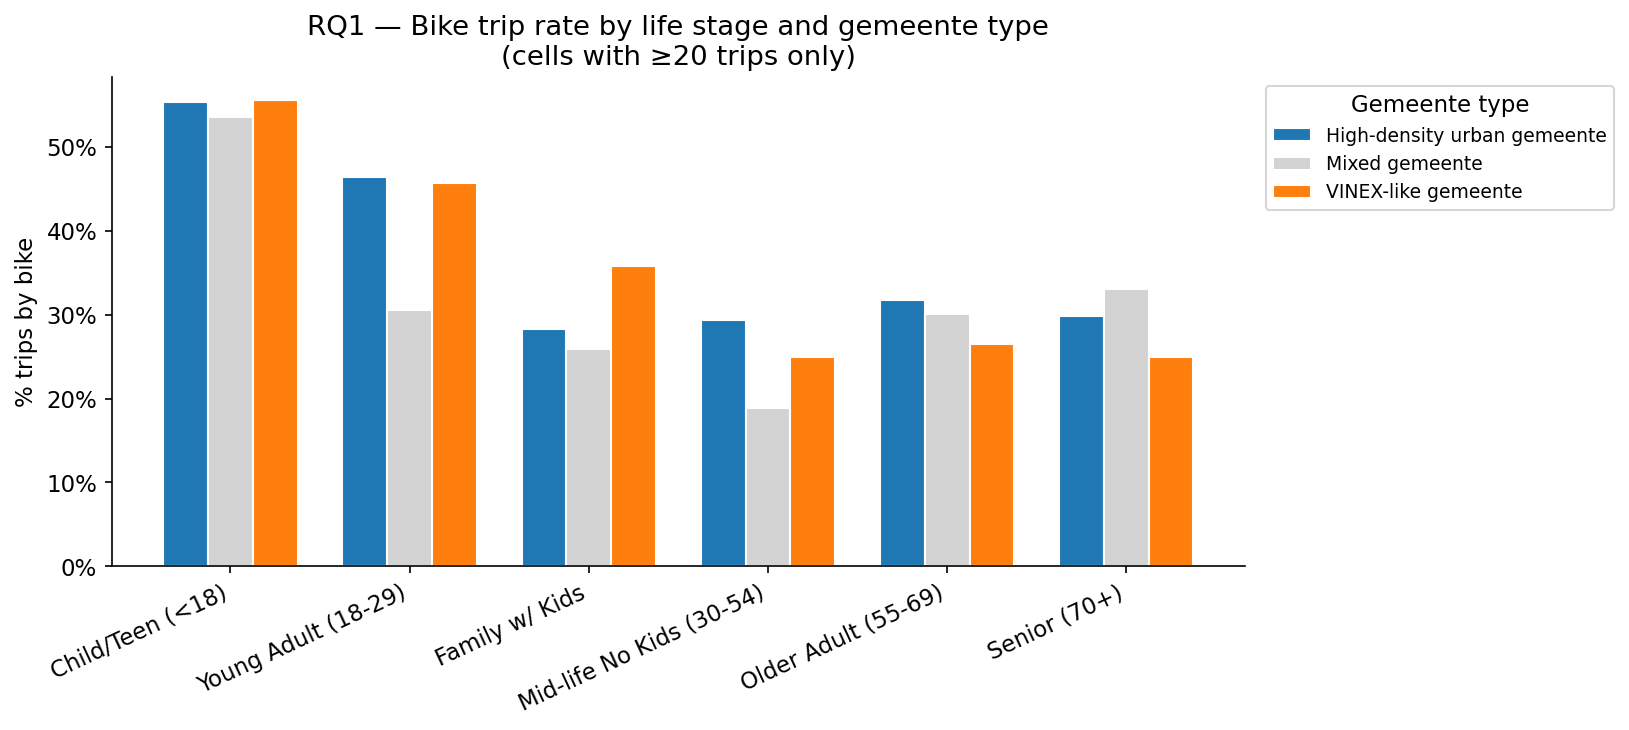

Key observation: which life stage × type combination has highest/lowest bike rate?
  Child/Teen (<18)                    max=55.6% (VINEX-like gemeente)  min=53.5% (Mixed gemeente)
  Young Adult (18-29)                 max=46.4% (High-density urban gemeente)  min=30.6% (Mixed gemeente)
  Family w/ Kids                      max=35.8% (VINEX-like gemeente)  min=26.0% (Mixed gemeente)
  Mid-life No Kids (30-54)            max=29.4% (High-density urban gemeente)  min=18.9% (Mixed gemeente)
  Older Adult (55-69)                 max=31.8% (High-density urban gemeente)  min=26.5% (VINEX-like gemeente)
  Senior (70+)                        max=33.0% (Mixed gemeente)  min=25.0% (VINEX-like gemeente)


In [40]:
# ── 4b. RQ1: bike rate by life stage × neighbourhood type ─────────────────────
rq1_eda = (rq1_model.groupby(["life_stage", "dominant_type"])["is_bike"]
           .agg(["mean", "count"]).reset_index())
rq1_eda = rq1_eda[rq1_eda["count"] >= 20]   # reliability filter
pivot = rq1_eda.pivot(index="life_stage", columns="dominant_type", values="mean")
pivot = pivot.reindex([ls for ls in LIFE_ORDER if ls in pivot.index])

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(pivot))
width = 0.25
for i, col in enumerate(pivot.columns):
    bars = ax.bar(x + i * width, pivot[col], width,
                  label=col, color=TYPE_COL.get(col, "grey"), edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels(pivot.index, rotation=25, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("% trips by bike")
ax.set_title("RQ1 — Bike trip rate by life stage and gemeente type\n"
             "(cells with ≥20 trips only)")
ax.legend(title="Gemeente type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(OUT / "fig_t2_rq1_01_bike_rate_lifestage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key observation: which life stage × type combination has highest/lowest bike rate?")
for ls in LIFE_ORDER:
    row = pivot.loc[ls] if ls in pivot.index else None
    if row is not None:
        print(f"  {ls:<35s} max={row.max():.1%} ({row.idxmax()})  min={row.min():.1%} ({row.idxmin()})")


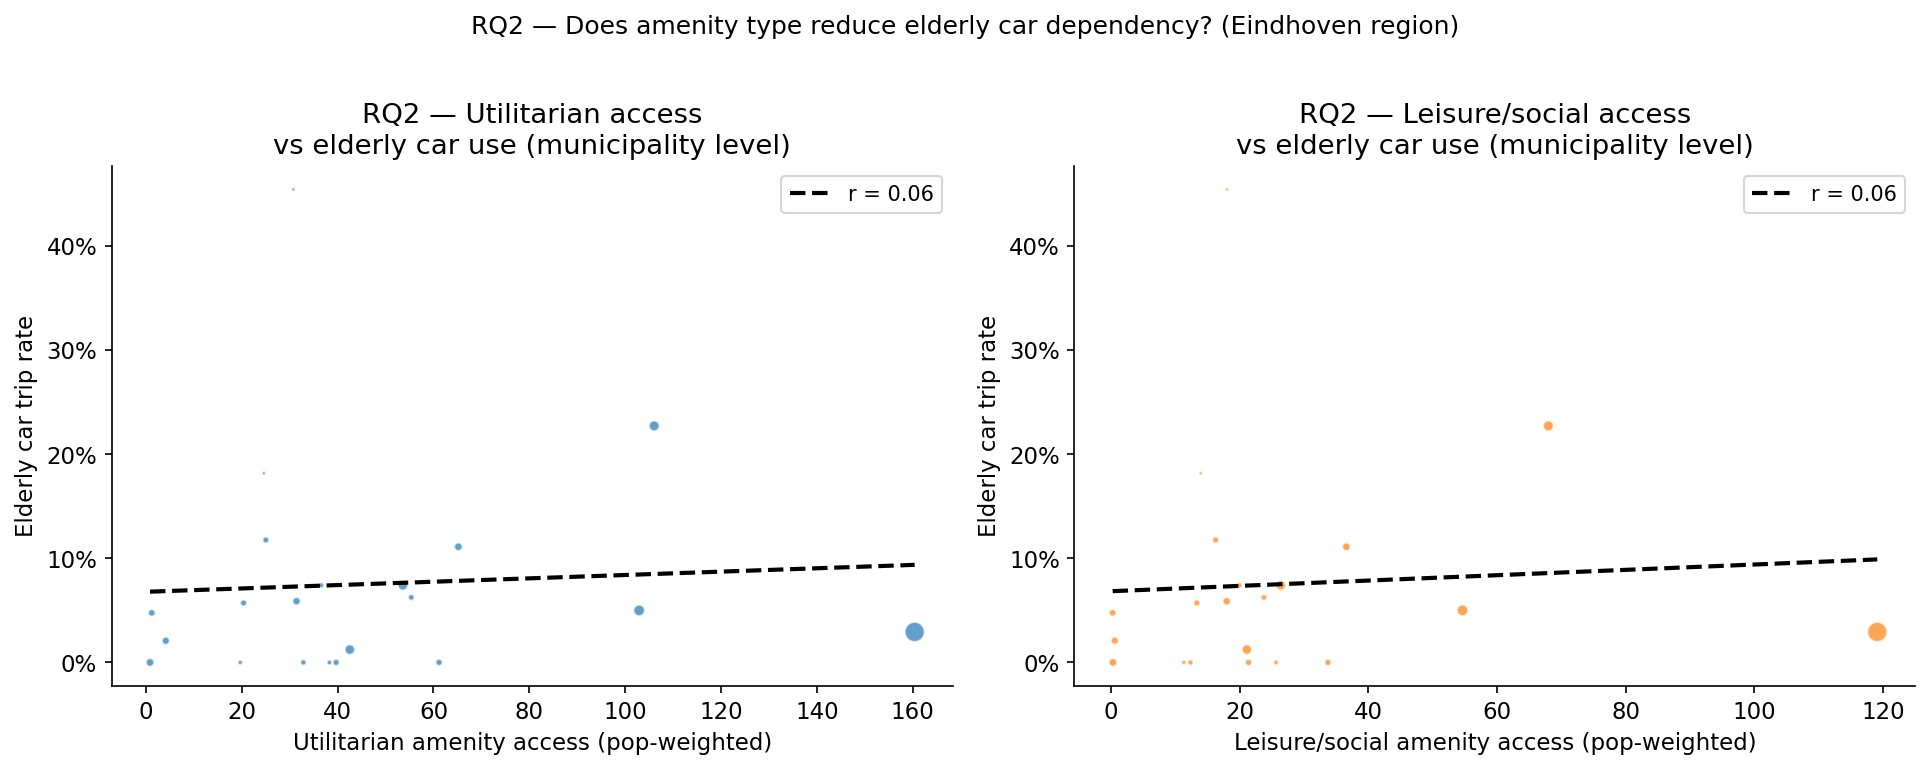

In [41]:
# ── 4c. RQ2: amenity access vs elderly car use ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, label, color in zip(
    axes,
    ["pop_weighted_utilitarian_access", "pop_weighted_leisure_social_access"],
    ["Utilitarian amenity access (pop-weighted)", "Leisure/social amenity access (pop-weighted)"],
    ["#1f77b4", "#ff7f0e"]
):
    # Aggregate to municipality level for cleaner scatter
    muni_plot = (rq2_model.groupby("Wogem_DANS24")
                 .agg(car_rate=("is_car","mean"), feat_val=(feat,"mean"),
                      n=("is_car","count"))
                 .reset_index())
    sc = ax.scatter(muni_plot["feat_val"], muni_plot["car_rate"],
                    s=muni_plot["n"] * 0.3, color=color, alpha=0.7, edgecolors="white")
    # OLS fit
    xi, yi = muni_plot["feat_val"].values, muni_plot["car_rate"].values
    valid  = ~(np.isnan(xi) | np.isnan(yi))
    if valid.sum() >= 4:
        m, b  = np.polyfit(xi[valid], yi[valid], 1)
        r2v   = np.corrcoef(xi[valid], yi[valid])[0, 1] ** 2
        xl    = np.linspace(xi[valid].min(), xi[valid].max(), 100)
        ax.plot(xl, m * xl + b, "k--", lw=2, label=f"r = {np.sqrt(r2v):.2f}")
        ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel(label); ax.set_ylabel("Elderly car trip rate")
    ax.set_title(f"RQ2 — {label.split(' ')[0]} access\nvs elderly car use (municipality level)")

plt.suptitle("RQ2 — Does amenity type reduce elderly car dependency? (Eindhoven region)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "fig_t2_rq2_01_amenity_vs_car_use.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Method Choice & Justification

### Why three models?

| Model | Role | Strength | Limitation |
|-------|------|----------|------------|
| **Logistic Regression** | Interpretable baseline | Linear, fast, coefficients meaningful | Cannot capture interactions or non-linearities |
| **Random Forest** | Main model | Captures non-linear effects and interactions between life stage and neighbourhood type; robust to outliers | Black-box; needs SHAP for interpretation |
| **XGBoost** | Comparison | State-of-the-art performance; regularisation; handles class imbalance via `scale_pos_weight` | More hyperparameters |

### Why AUC-ROC?
- Binary target (is_bike / is_car) makes AUC the correct metric
- AUC is insensitive to class imbalance — important since only 32.6% of trips are by bike (RQ1) and 5.8% by car (RQ2)
- AUC > 0.70 = acceptable, > 0.75 = good, > 0.80 = very good

### Why SHAP?
SHAP (SHapley Additive exPlanations) directly answers both RQs:
- **RQ1:** The SHAP heatmap by life stage shows which features drive bike choice differently for each group
- **RQ2:** Comparing |SHAP| for utilitarian vs. leisure/social access answers which type matters more


## 6. RQ1 — Classification Models (Predicting is_bike)

In [42]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 6a. Logistic Regression (baseline) ───────────────────────────────────────
lr1 = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
cv_auc_lr1 = cross_val_score(lr1, X1_imp, y1, scoring="roc_auc", cv=cv_strat)
lr1.fit(X1_imp, y1)

coef_lr1 = pd.Series(lr1.coef_[0], index=FEAT_COLS_RQ1).sort_values(key=abs, ascending=False)
print(f"Logistic Regression  AUC: {cv_auc_lr1.mean():.3f} ± {cv_auc_lr1.std():.3f}")
print("\nTop coefficients (log-odds):")
print(coef_lr1.round(3).head(8).to_string())
print("\n→ Negative = reduces P(bike)  |  Positive = increases P(bike)")


Logistic Regression  AUC: 0.606 ± 0.010

Top coefficients (log-odds):
ls_Mid-life No Kids (30-54)   -0.608
ls_Family w/ Kids             -0.572
ls_Senior (70+)                0.514
ls_Young Adult (18-29)        -0.477
life_stage_code               -0.281
ls_Older Adult (55-69)         0.149
pct_cycling_season             0.105
avg_dist_gp_km                 0.086

→ Negative = reduces P(bike)  |  Positive = increases P(bike)


In [43]:
# ── 6b. Random Forest (main model) ───────────────────────────────────────────
param_grid_rf = {
    "n_estimators"    : [200, 400],
    "max_depth"       : [3, 5, None],
    "min_samples_leaf": [2, 4],
}
rf1_cv = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, scoring="roc_auc", cv=cv_strat, n_jobs=-1
)
rf1_cv.fit(X1_imp, y1)
rf1_best = rf1_cv.best_estimator_
cv_auc_rf1 = cross_val_score(rf1_best, X1_imp, y1, scoring="roc_auc", cv=cv_strat)

print(f"Random Forest  best params : {rf1_cv.best_params_}")
print(f"Random Forest  AUC         : {cv_auc_rf1.mean():.3f} ± {cv_auc_rf1.std():.3f}")


Random Forest  best params : {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Random Forest  AUC         : 0.704 ± 0.004


In [44]:
# ── 6c. XGBoost / GBM ─────────────────────────────────────────────────────────
param_grid_gb = {
    "n_estimators" : [100, 300],
    "max_depth"    : [2, 3],
    "learning_rate": [0.05, 0.1],
    "subsample"    : [0.8, 1.0],
}
gb1_base = (XGBClassifier(random_state=42, n_jobs=-1, verbosity=0, eval_metric="auc")
            if HAS_XGB else GradientBoostingClassifier(random_state=42))
gb1_cv = GridSearchCV(gb1_base, param_grid_gb, scoring="roc_auc", cv=cv_strat, n_jobs=-1)
gb1_cv.fit(X1_imp, y1)
gb1_best = gb1_cv.best_estimator_
cv_auc_gb1 = cross_val_score(gb1_best, X1_imp, y1, scoring="roc_auc", cv=cv_strat)

print(f"{MODEL_NAME}  best params : {gb1_cv.best_params_}")
print(f"{MODEL_NAME}  AUC         : {cv_auc_gb1.mean():.3f} ± {cv_auc_gb1.std():.3f}")


XGBoost  best params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
XGBoost  AUC         : 0.689 ± 0.007


## 7. RQ1 — Evaluation & SHAP Interpretability

RQ1 Model Comparison — 5-fold Stratified CV AUC-ROC
                     CV AUC μ  CV AUC σ
Model                                  
Logistic Regression     0.606     0.010
Random Forest           0.704     0.004
XGBoost                 0.689     0.007
Reference: >0.70 = acceptable  |  >0.75 = good  |  >0.80 = very good


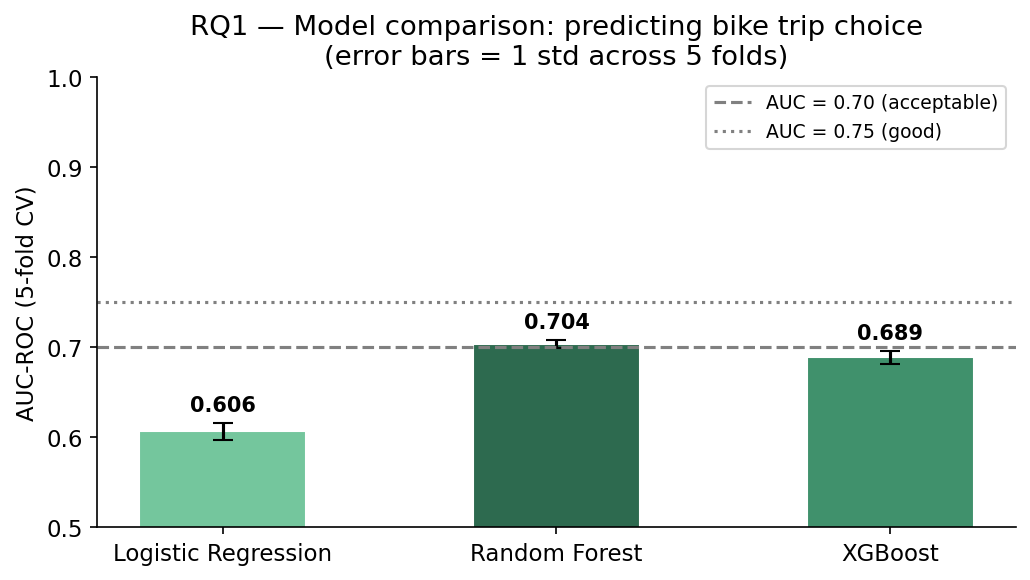

In [45]:
# ── Model comparison table and chart ─────────────────────────────────────────
rq1_results = pd.DataFrame({
    "Model"    : ["Logistic Regression", "Random Forest", MODEL_NAME],
    "CV AUC μ" : [cv_auc_lr1.mean(), cv_auc_rf1.mean(), cv_auc_gb1.mean()],
    "CV AUC σ" : [cv_auc_lr1.std(),  cv_auc_rf1.std(),  cv_auc_gb1.std()],
}).set_index("Model")
rq1_results.to_csv(OUT / "table_rq1_model_comparison.csv")

print("RQ1 Model Comparison — 5-fold Stratified CV AUC-ROC")
print("=" * 50)
print(rq1_results.round(3).to_string())
print("=" * 50)
print("Reference: >0.70 = acceptable  |  >0.75 = good  |  >0.80 = very good")

fig, ax = plt.subplots(figsize=(7, 4))
colors = [PALETTE[2], PALETTE[0], PALETTE[1]]
ax.bar(rq1_results.index, rq1_results["CV AUC μ"],
       yerr=rq1_results["CV AUC σ"], capsize=5,
       color=colors, edgecolor="white", width=0.5)
ax.axhline(0.70, ls="--", color="grey", lw=1.5, label="AUC = 0.70 (acceptable)")
ax.axhline(0.75, ls=":",  color="grey", lw=1.5, label="AUC = 0.75 (good)")
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("AUC-ROC (5-fold CV)")
ax.set_title("RQ1 — Model comparison: predicting bike trip choice\n"
             "(error bars = 1 std across 5 folds)")
ax.legend(fontsize=9)
for i, (_, row) in enumerate(rq1_results.iterrows()):
    ax.text(i, row["CV AUC μ"] + row["CV AUC σ"] + 0.012,
            f"{row['CV AUC μ']:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "fig_t2_rq1_02_auc_comparison.png", dpi=150)
plt.show()


In [46]:
# ── SHAP: compute values for Random Forest (main model) ──────────────────────
# Sample 500 trips for speed; results are representative
sample_idx = np.random.RandomState(42).choice(len(X1_imp), 500, replace=False)
X1_sample  = X1_imp.iloc[sample_idx].reset_index(drop=True)

print("Computing SHAP values (this takes ~3 minutes)...")
explainer_rf1 = shap.Explainer(rf1_best, X1_imp)
shap_vals_obj = explainer_rf1(X1_sample)

# shap_vals_obj.values: (500, n_features, 2) for binary RF → take class 1 (is_bike)
sv = shap_vals_obj.values
if sv.ndim == 3:
    sv = sv[:, :, 1]

print(f"SHAP values shape: {sv.shape}  (samples × features)")
print(f"Max |SHAP| value : {np.abs(sv).max():.4f}")


Computing SHAP values (this takes ~3 minutes)...


 99%|===================| 993/1000 [01:25<00:00]        

SHAP values shape: (500, 22)  (samples × features)
Max |SHAP| value : 0.2690


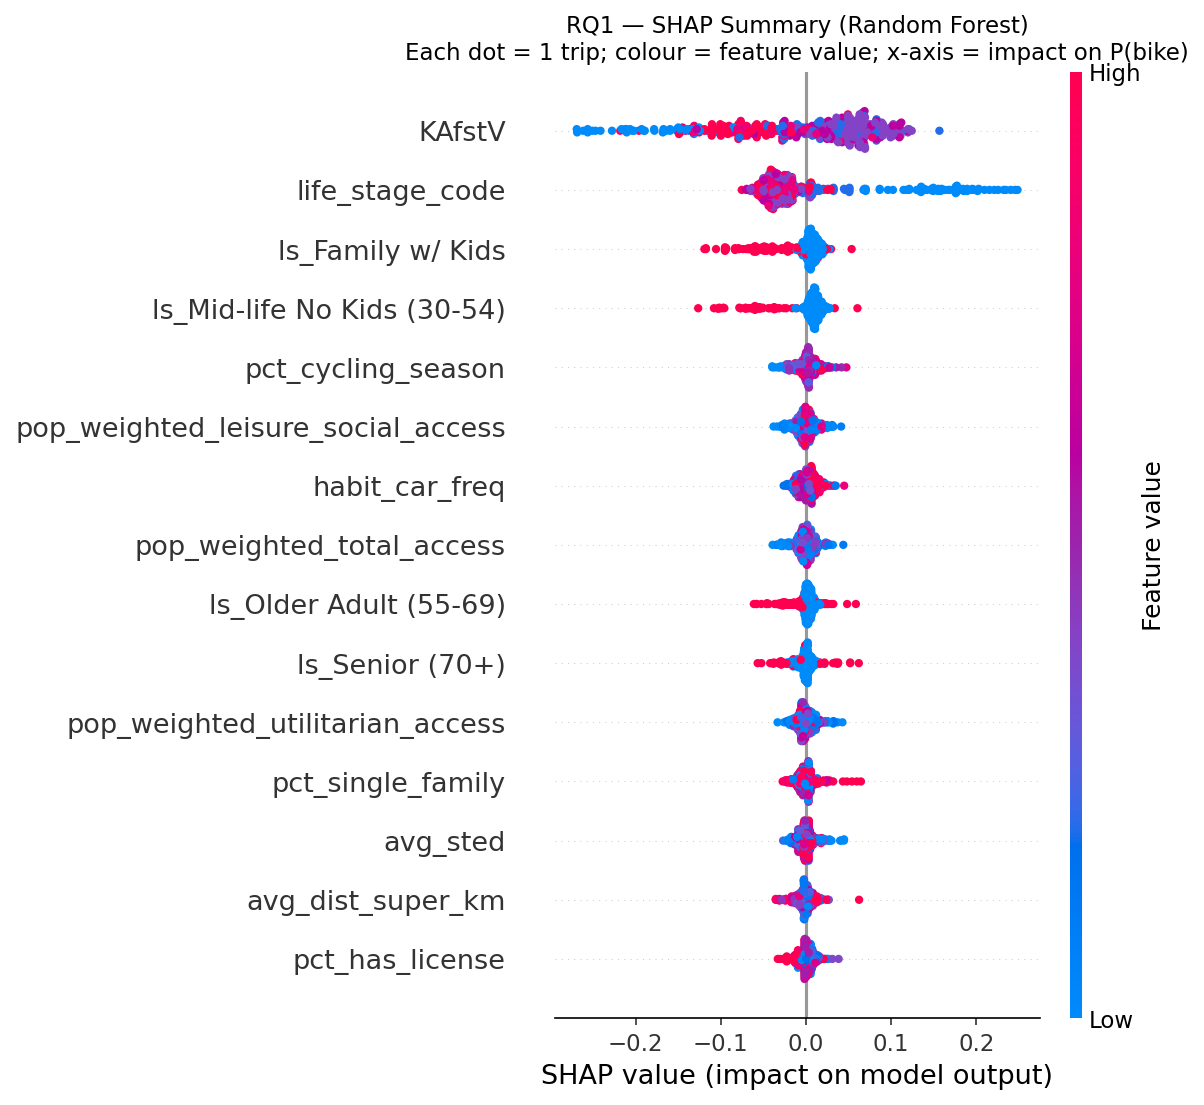

In [47]:
# ── SHAP Summary Plot ─────────────────────────────────────────────────────────
# Normalise features for display only (removes scale distortion from avg_sted)
scaler1        = StandardScaler()
X1_sample_sc   = pd.DataFrame(scaler1.fit_transform(X1_sample), columns=FEAT_COLS_RQ1)

plt.figure(figsize=(9, 7))
shap.summary_plot(sv, X1_sample_sc, feature_names=FEAT_COLS_RQ1,
                  show=False, max_display=15)
plt.title("RQ1 — SHAP Summary (Random Forest)\n"
          "Each dot = 1 trip; colour = feature value; x-axis = impact on P(bike)",
          fontsize=11)
plt.tight_layout()
plt.savefig(OUT / "fig_t2_rq1_03_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


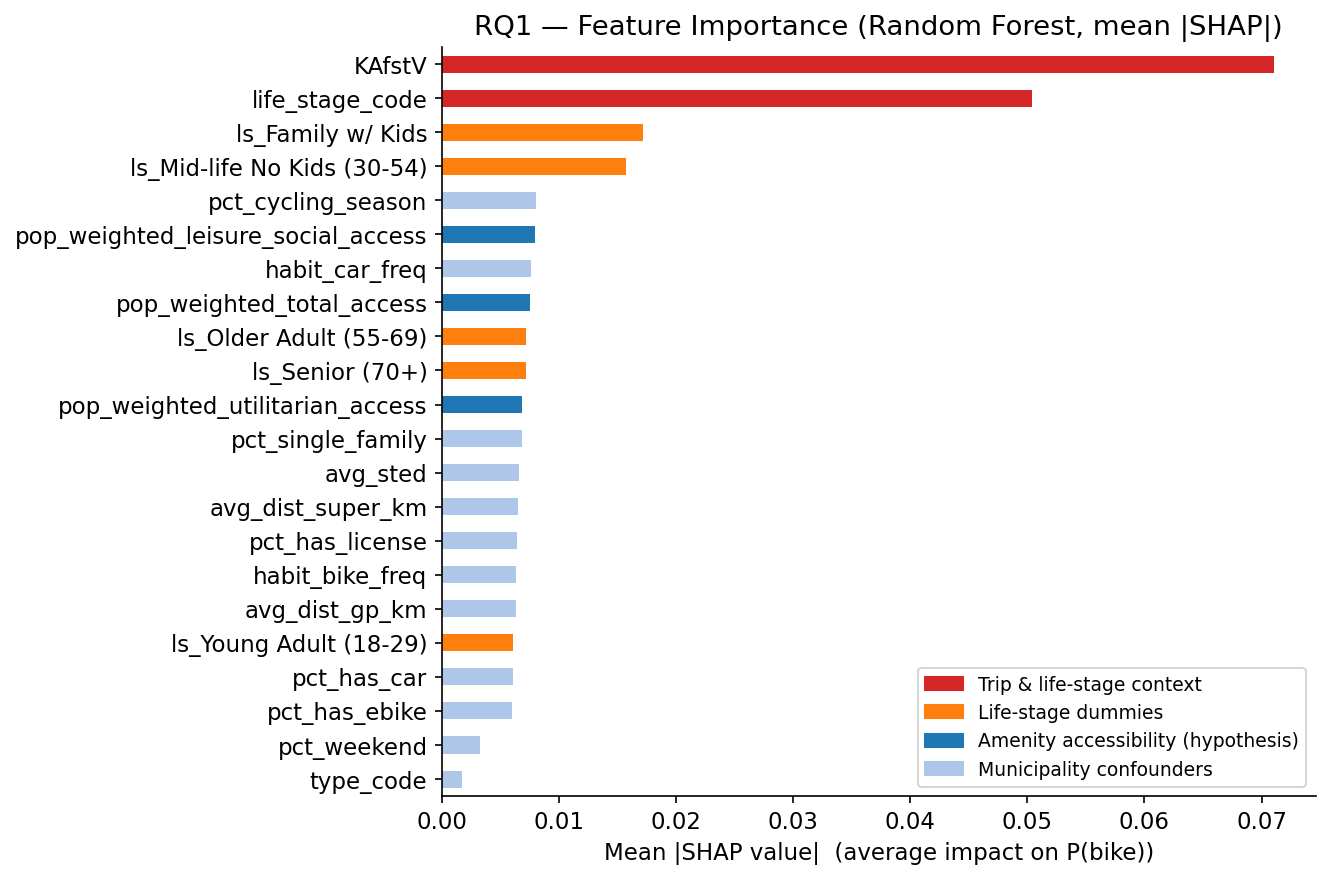

SHAP importance ranking:
KAfstV                                0.07106
life_stage_code                       0.05038
ls_Family w/ Kids                     0.01716
ls_Mid-life No Kids (30-54)           0.01569
pct_cycling_season                    0.00804
pop_weighted_leisure_social_access    0.00791
habit_car_freq                        0.00760
pop_weighted_total_access             0.00754
ls_Older Adult (55-69)                0.00717
ls_Senior (70+)                       0.00716
pop_weighted_utilitarian_access       0.00685
pct_single_family                     0.00680
avg_sted                              0.00656
avg_dist_super_km                     0.00652
pct_has_license                       0.00639
habit_bike_freq                       0.00634
avg_dist_gp_km                        0.00631
ls_Young Adult (18-29)                0.00604
pct_has_car                           0.00603
pct_has_ebike                         0.00598
pct_weekend                           0.00321
type_code

In [48]:
# ── SHAP Feature Importance Bar ───────────────────────────────────────────────
shap_mean_rf1 = pd.Series(
    np.abs(sv).mean(axis=0), index=FEAT_COLS_RQ1
).sort_values(ascending=False)

# Colour by feature tier
def feat_color(f):
    if "access" in f: return "#1f77b4"
    if f in ["KAfstV", "life_stage_code"]: return "#d62728"
    if f.startswith("ls_"): return "#ff7f0e"
    return "#aec7e8"

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = [feat_color(f) for f in shap_mean_rf1.index]
shap_mean_rf1.plot.barh(ax=ax, color=colors_bar)
ax.set_xlabel("Mean |SHAP value|  (average impact on P(bike))")
ax.set_title("RQ1 — Feature Importance (Random Forest, mean |SHAP|)")
ax.invert_yaxis()

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#d62728", label="Trip & life-stage context"),
    Patch(color="#ff7f0e", label="Life-stage dummies"),
    Patch(color="#1f77b4", label="Amenity accessibility (hypothesis)"),
    Patch(color="#aec7e8", label="Municipality confounders"),
], fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(OUT / "fig_t2_rq1_04_shap_bar.png", dpi=150)
plt.show()

print("SHAP importance ranking:")
print(shap_mean_rf1.round(5).to_string())


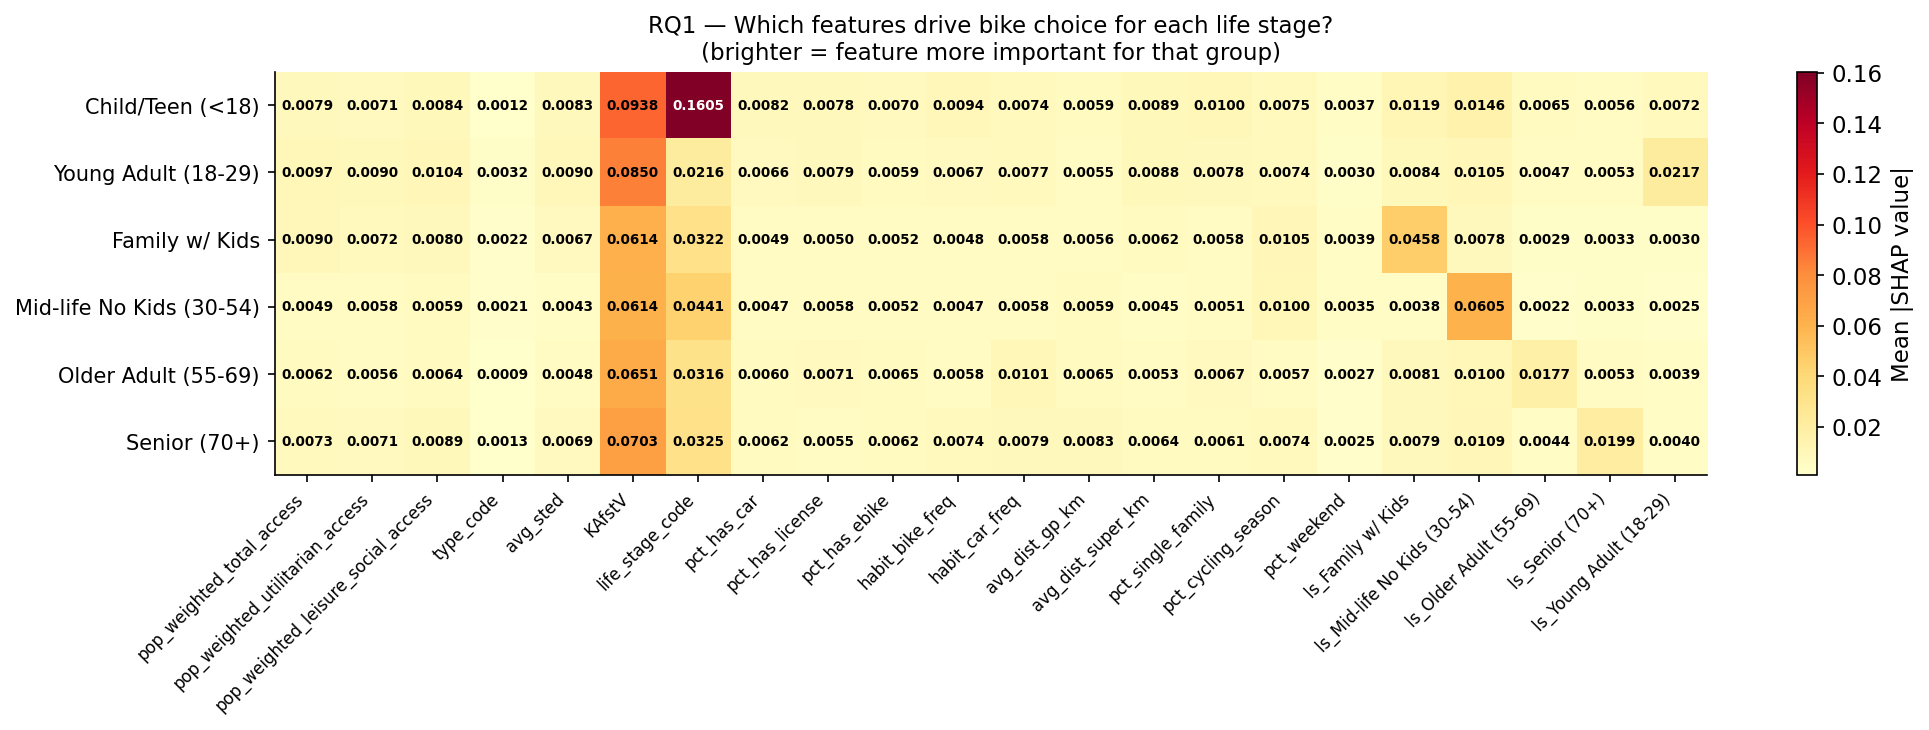

SHAP importance by life stage:
                          pop_weighted_total_access  pop_weighted_utilitarian_access  pop_weighted_leisure_social_access  type_code  avg_sted  KAfstV  life_stage_code  pct_has_car  pct_has_license  pct_has_ebike  habit_bike_freq  habit_car_freq  avg_dist_gp_km  avg_dist_super_km  pct_single_family  pct_cycling_season  pct_weekend  ls_Family w/ Kids  ls_Mid-life No Kids (30-54)  ls_Older Adult (55-69)  ls_Senior (70+)  ls_Young Adult (18-29)
Child/Teen (<18)                             0.0079                           0.0071                              0.0084     0.0012    0.0083  0.0938           0.1605       0.0082           0.0078         0.0070           0.0094          0.0074          0.0059             0.0089             0.0100              0.0075       0.0037             0.0119                       0.0146                  0.0065           0.0056                  0.0072
Young Adult (18-29)                          0.0097                           0

In [49]:
# ── SHAP Heatmap by Life Stage (directly answers RQ1) ────────────────────────
rq1_sample = rq1_model.iloc[sample_idx].reset_index(drop=True)
shap_ls = {}
for ls in LIFE_ORDER:
    mask = rq1_sample["life_stage"] == ls
    if mask.sum() >= 10:
        shap_ls[ls] = pd.Series(np.abs(sv[mask.values]).mean(axis=0),
                                 index=FEAT_COLS_RQ1)

if shap_ls:
    shap_ls_df = pd.DataFrame(shap_ls).T

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(shap_ls_df.values, aspect="auto", cmap="YlOrRd")

    ax.set_xticks(range(len(FEAT_COLS_RQ1)))
    ax.set_xticklabels(FEAT_COLS_RQ1, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(shap_ls_df)))
    ax.set_yticklabels(shap_ls_df.index, fontsize=10)

    # ── Annotate each cell with its value ────────────────────────────────────
    vmin = shap_ls_df.values.min()
    vmax = shap_ls_df.values.max()
    threshold = vmin + 0.6 * (vmax - vmin)   # cells darker than this → white text

    for row_idx in range(shap_ls_df.shape[0]):
        for col_idx in range(shap_ls_df.shape[1]):
            val = shap_ls_df.values[row_idx, col_idx]
            # white text on dark cells, black text on light cells
            text_color = "white" if val > threshold else "black"
            ax.text(
                col_idx, row_idx,
                f"{val:.4f}",
                ha="center", va="center",
                fontsize=6.5,
                color=text_color,
                fontweight="bold"
            )
    # ─────────────────────────────────────────────────────────────────────────

    plt.colorbar(im, ax=ax, label="Mean |SHAP value|")
    ax.set_title("RQ1 — Which features drive bike choice for each life stage?\n"
                 "(brighter = feature more important for that group)",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT / "fig_t2_rq1_05_shap_heatmap_lifestage.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("SHAP importance by life stage:")
    print(shap_ls_df.round(4).to_string())

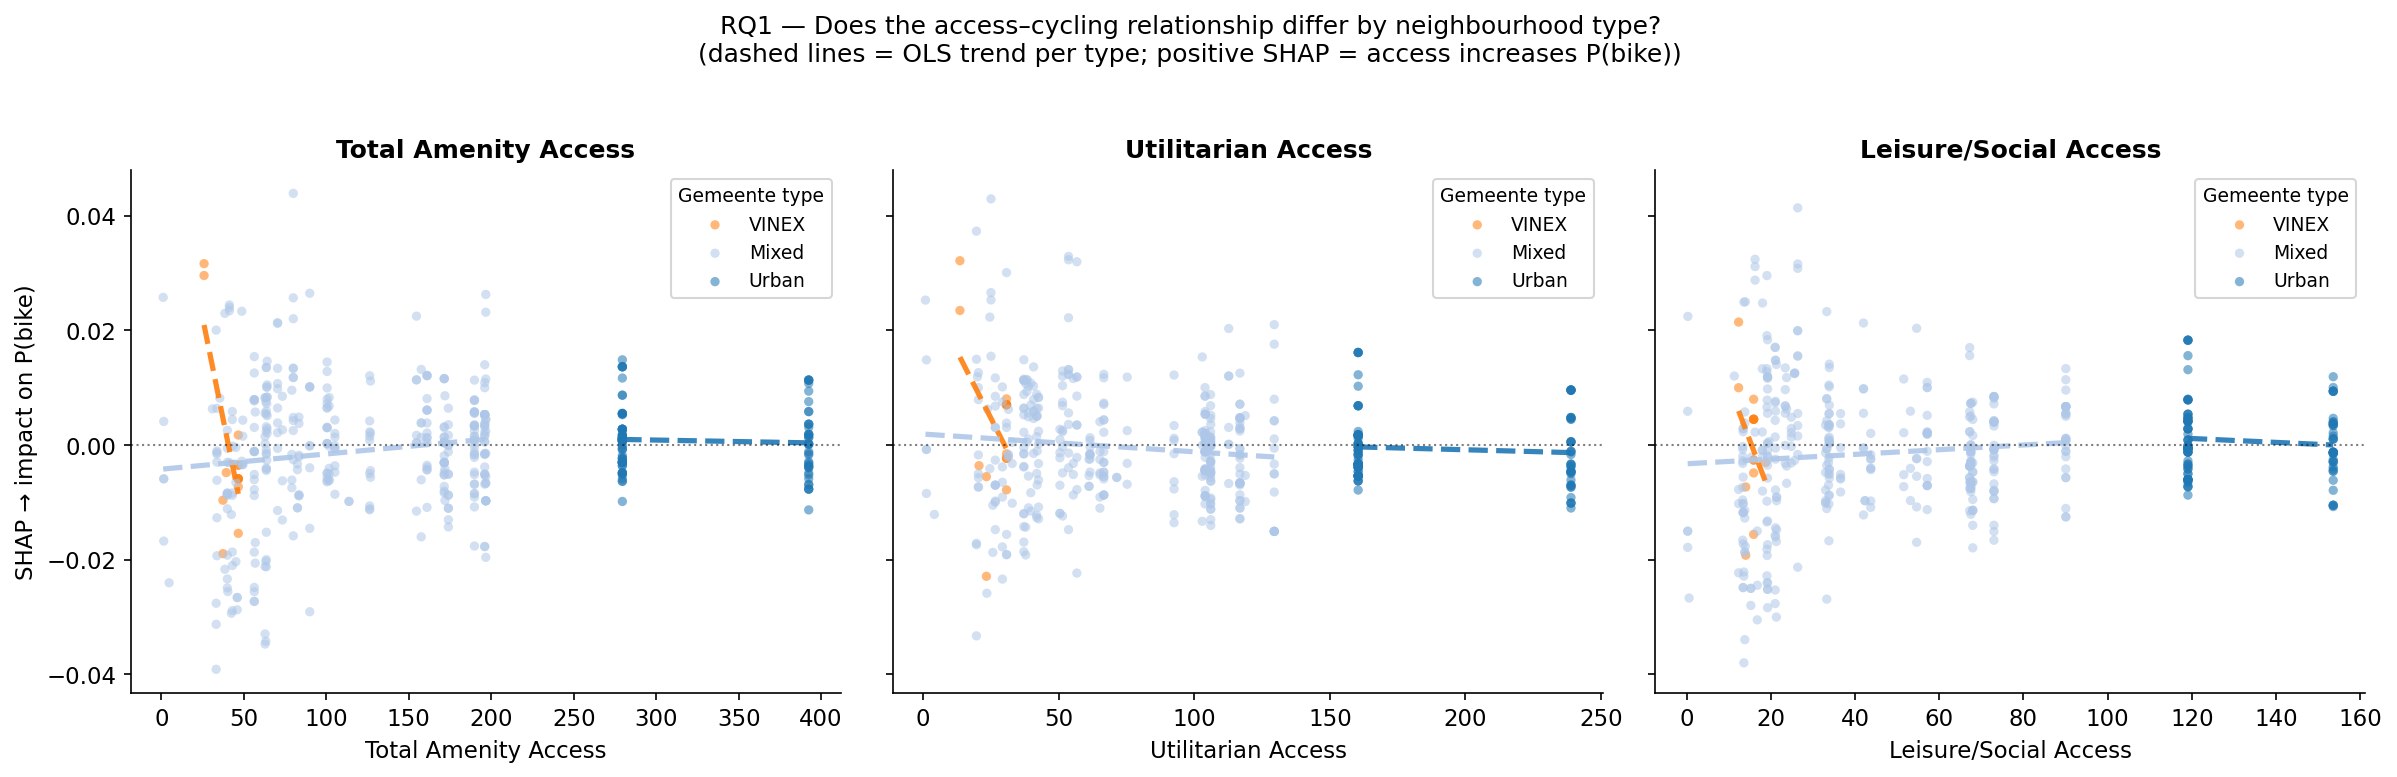

In [50]:
# ── SHAP Dependence: access effect by neighbourhood type ─────────────────────
access_feats = [f for f in ["pop_weighted_total_access",
                             "pop_weighted_utilitarian_access",
                             "pop_weighted_leisure_social_access"]
                if f in FEAT_COLS_RQ1]

if access_feats and "type_code" in FEAT_COLS_RQ1:
    type_labels = {0: "VINEX", 1: "Mixed", 2: "Urban"}
    type_colors = {0: "#ff7f0e", 1: "#aec7e8", 2: "#1f77b4"}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    titles = ["Total Amenity Access", "Utilitarian Access", "Leisure/Social Access"]

    for ax, feat, title in zip(axes, access_feats, titles):
        fi = FEAT_COLS_RQ1.index(feat)

        # Plot each neighbourhood type separately for clear legend
        for type_code, label in type_labels.items():
            mask = (X1_sample["type_code"].round() == type_code)
            if mask.sum() == 0:
                continue
            ax.scatter(
                X1_sample.loc[mask].iloc[:, fi],
                sv[mask.values, fi],
                label=label,
                color=type_colors[type_code],
                alpha=0.55, s=20, edgecolors="none"
            )
            # OLS trend line per type
            xi = X1_sample.loc[mask].iloc[:, fi].values
            yi = sv[mask.values, fi]
            if len(xi) >= 5:
                m, b = np.polyfit(xi, yi, 1)
                xl   = np.linspace(xi.min(), xi.max(), 100)
                ax.plot(xl, m * xl + b, color=type_colors[type_code],
                        lw=2.5, ls="--", alpha=0.9)

        ax.axhline(0, color="black", lw=1, ls=":", alpha=0.5)
        ax.set_xlabel(title, fontsize=11)
        ax.set_ylabel("SHAP → impact on P(bike)" if ax == axes[0] else "")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(title="Gemeente type", fontsize=9, title_fontsize=9)

    plt.suptitle(
        "RQ1 — Does the access–cycling relationship differ by neighbourhood type?\n"
        "(dashed lines = OLS trend per type; positive SHAP = access increases P(bike))",
        fontsize=12, y=1.03
    )
    plt.tight_layout()
    plt.savefig(OUT / "fig_t2_rq1_06_shap_dependence_type.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. RQ2 — Classification Models (Predicting Elderly Car Use)

In [51]:
cv_strat2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
neg, pos  = (y2 == 0).sum(), (y2 == 1).sum()
scale_pw  = neg / pos   # for XGBoost

param_grid_rf2 = {"n_estimators":[200,400], "max_depth":[3,5], "min_samples_leaf":[5,10]}
param_grid_gb2 = {"n_estimators":[100,300], "max_depth":[2,3],
                  "learning_rate":[0.05,0.1], "subsample":[0.8,1.0]}

# ── 8a. Logistic Regression ───────────────────────────────────────────────────
lr2 = LogisticRegression(max_iter=1000, random_state=42, C=0.1,
                          class_weight="balanced")
cv_auc_lr2 = cross_val_score(lr2, X2_imp, y2, scoring="roc_auc", cv=cv_strat2)
lr2.fit(X2_imp, y2)

coef_lr2 = pd.Series(lr2.coef_[0], index=FEAT_COLS_RQ2).sort_values(key=abs, ascending=False)
print(f"Logistic Regression  AUC: {cv_auc_lr2.mean():.3f} ± {cv_auc_lr2.std():.3f}")
print("\nTop coefficients (log-odds, class_weight=balanced):")
print(coef_lr2.round(3).head(8).to_string())


Logistic Regression  AUC: 0.742 ± 0.061

Top coefficients (log-odds, class_weight=balanced):
habit_car_freq       0.843
KAfstV               0.457
avg_dist_gp_km      -0.454
pct_has_car          0.422
habit_bike_freq      0.203
pct_has_license     -0.104
avg_dist_super_km    0.087
type_code            0.040


In [52]:
# ── 8b. Random Forest ─────────────────────────────────────────────────────────
rf2_cv = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
    param_grid_rf2, scoring="roc_auc", cv=cv_strat2, n_jobs=-1
)
rf2_cv.fit(X2_imp, y2)
rf2_best = rf2_cv.best_estimator_
cv_auc_rf2 = cross_val_score(rf2_best, X2_imp, y2, scoring="roc_auc", cv=cv_strat2)

print(f"Random Forest  best params : {rf2_cv.best_params_}")
print(f"Random Forest  AUC         : {cv_auc_rf2.mean():.3f} ± {cv_auc_rf2.std():.3f}")


Random Forest  best params : {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest  AUC         : 0.765 ± 0.018


In [53]:
# ── 8c. XGBoost / GBM (scale_pos_weight corrects class imbalance) ─────────────
gb2_base = (XGBClassifier(random_state=42, n_jobs=-1, verbosity=0,
                           eval_metric="auc", scale_pos_weight=scale_pw)
            if HAS_XGB else
            GradientBoostingClassifier(random_state=42, n_iter_no_change=10))
gb2_cv = GridSearchCV(gb2_base, param_grid_gb2, scoring="roc_auc", cv=cv_strat2, n_jobs=-1)
gb2_cv.fit(X2_imp, y2)
gb2_best = gb2_cv.best_estimator_
cv_auc_gb2 = cross_val_score(gb2_best, X2_imp, y2, scoring="roc_auc", cv=cv_strat2)

print(f"{MODEL_NAME}  best params : {gb2_cv.best_params_}")
print(f"{MODEL_NAME}  AUC         : {cv_auc_gb2.mean():.3f} ± {cv_auc_gb2.std():.3f}")


XGBoost  best params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
XGBoost  AUC         : 0.802 ± 0.046


## 9. RQ2 — Evaluation & SHAP Interpretability

RQ2 Model Comparison — 5-fold Stratified CV AUC-ROC
(elderly car use, Eindhoven region, class_weight=balanced)
                     CV AUC μ  CV AUC σ
Model                                  
Logistic Regression     0.742     0.061
Random Forest           0.765     0.018
XGBoost                 0.802     0.046
Reference: >0.70 = acceptable  |  >0.75 = good  |  >0.80 = very good


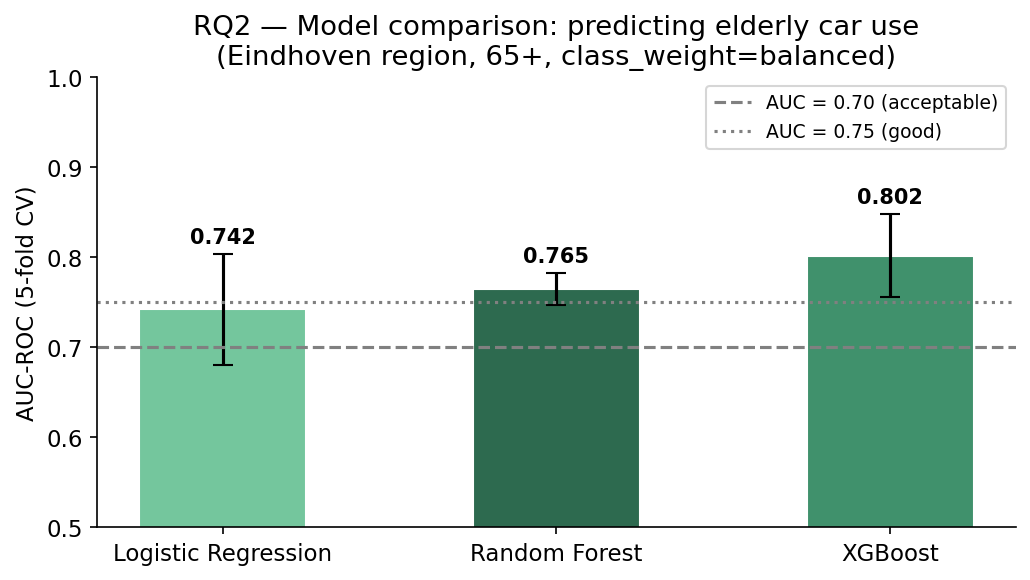

In [54]:
# ── Model comparison table and chart ─────────────────────────────────────────
rq2_results = pd.DataFrame({
    "Model"    : ["Logistic Regression", "Random Forest", MODEL_NAME],
    "CV AUC μ" : [cv_auc_lr2.mean(), cv_auc_rf2.mean(), cv_auc_gb2.mean()],
    "CV AUC σ" : [cv_auc_lr2.std(),  cv_auc_rf2.std(),  cv_auc_gb2.std()],
}).set_index("Model")
rq2_results.to_csv(OUT / "table_rq2_model_comparison.csv")

print("RQ2 Model Comparison — 5-fold Stratified CV AUC-ROC")
print("(elderly car use, Eindhoven region, class_weight=balanced)")
print("=" * 56)
print(rq2_results.round(3).to_string())
print("=" * 56)
print("Reference: >0.70 = acceptable  |  >0.75 = good  |  >0.80 = very good")

fig, ax = plt.subplots(figsize=(7, 4))
colors = [PALETTE[2], PALETTE[0], PALETTE[1]]
ax.bar(rq2_results.index, rq2_results["CV AUC μ"],
       yerr=rq2_results["CV AUC σ"], capsize=5,
       color=colors, edgecolor="white", width=0.5)
ax.axhline(0.70, ls="--", color="grey", lw=1.5, label="AUC = 0.70 (acceptable)")
ax.axhline(0.75, ls=":",  color="grey", lw=1.5, label="AUC = 0.75 (good)")
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("AUC-ROC (5-fold CV)")
ax.set_title("RQ2 — Model comparison: predicting elderly car use\n"
             "(Eindhoven region, 65+, class_weight=balanced)")
ax.legend(fontsize=9)
for i, (_, row) in enumerate(rq2_results.iterrows()):
    ax.text(i, row["CV AUC μ"] + row["CV AUC σ"] + 0.012,
            f"{row['CV AUC μ']:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "fig_t2_rq2_02_model_comparison.png", dpi=150)
plt.show()


In [55]:
# ── SHAP: compute values for Random Forest ────────────────────────────────────
sample_idx2 = np.random.RandomState(42).choice(len(X2_imp), min(500, len(X2_imp)), replace=False)
X2_sample   = X2_imp.iloc[sample_idx2].reset_index(drop=True)

print("Computing SHAP values for RQ2...")
explainer_rf2 = shap.Explainer(rf2_best, X2_imp)
shap_vals2    = explainer_rf2(X2_sample)
sv2 = shap_vals2.values
if sv2.ndim == 3:
    sv2 = sv2[:, :, 1]   # class is_car=1

print(f"SHAP values shape : {sv2.shape}")
print(f"Max |SHAP| value  : {np.abs(sv2).max():.4f}")


Computing SHAP values for RQ2...
SHAP values shape : (500, 13)
Max |SHAP| value  : 0.3392


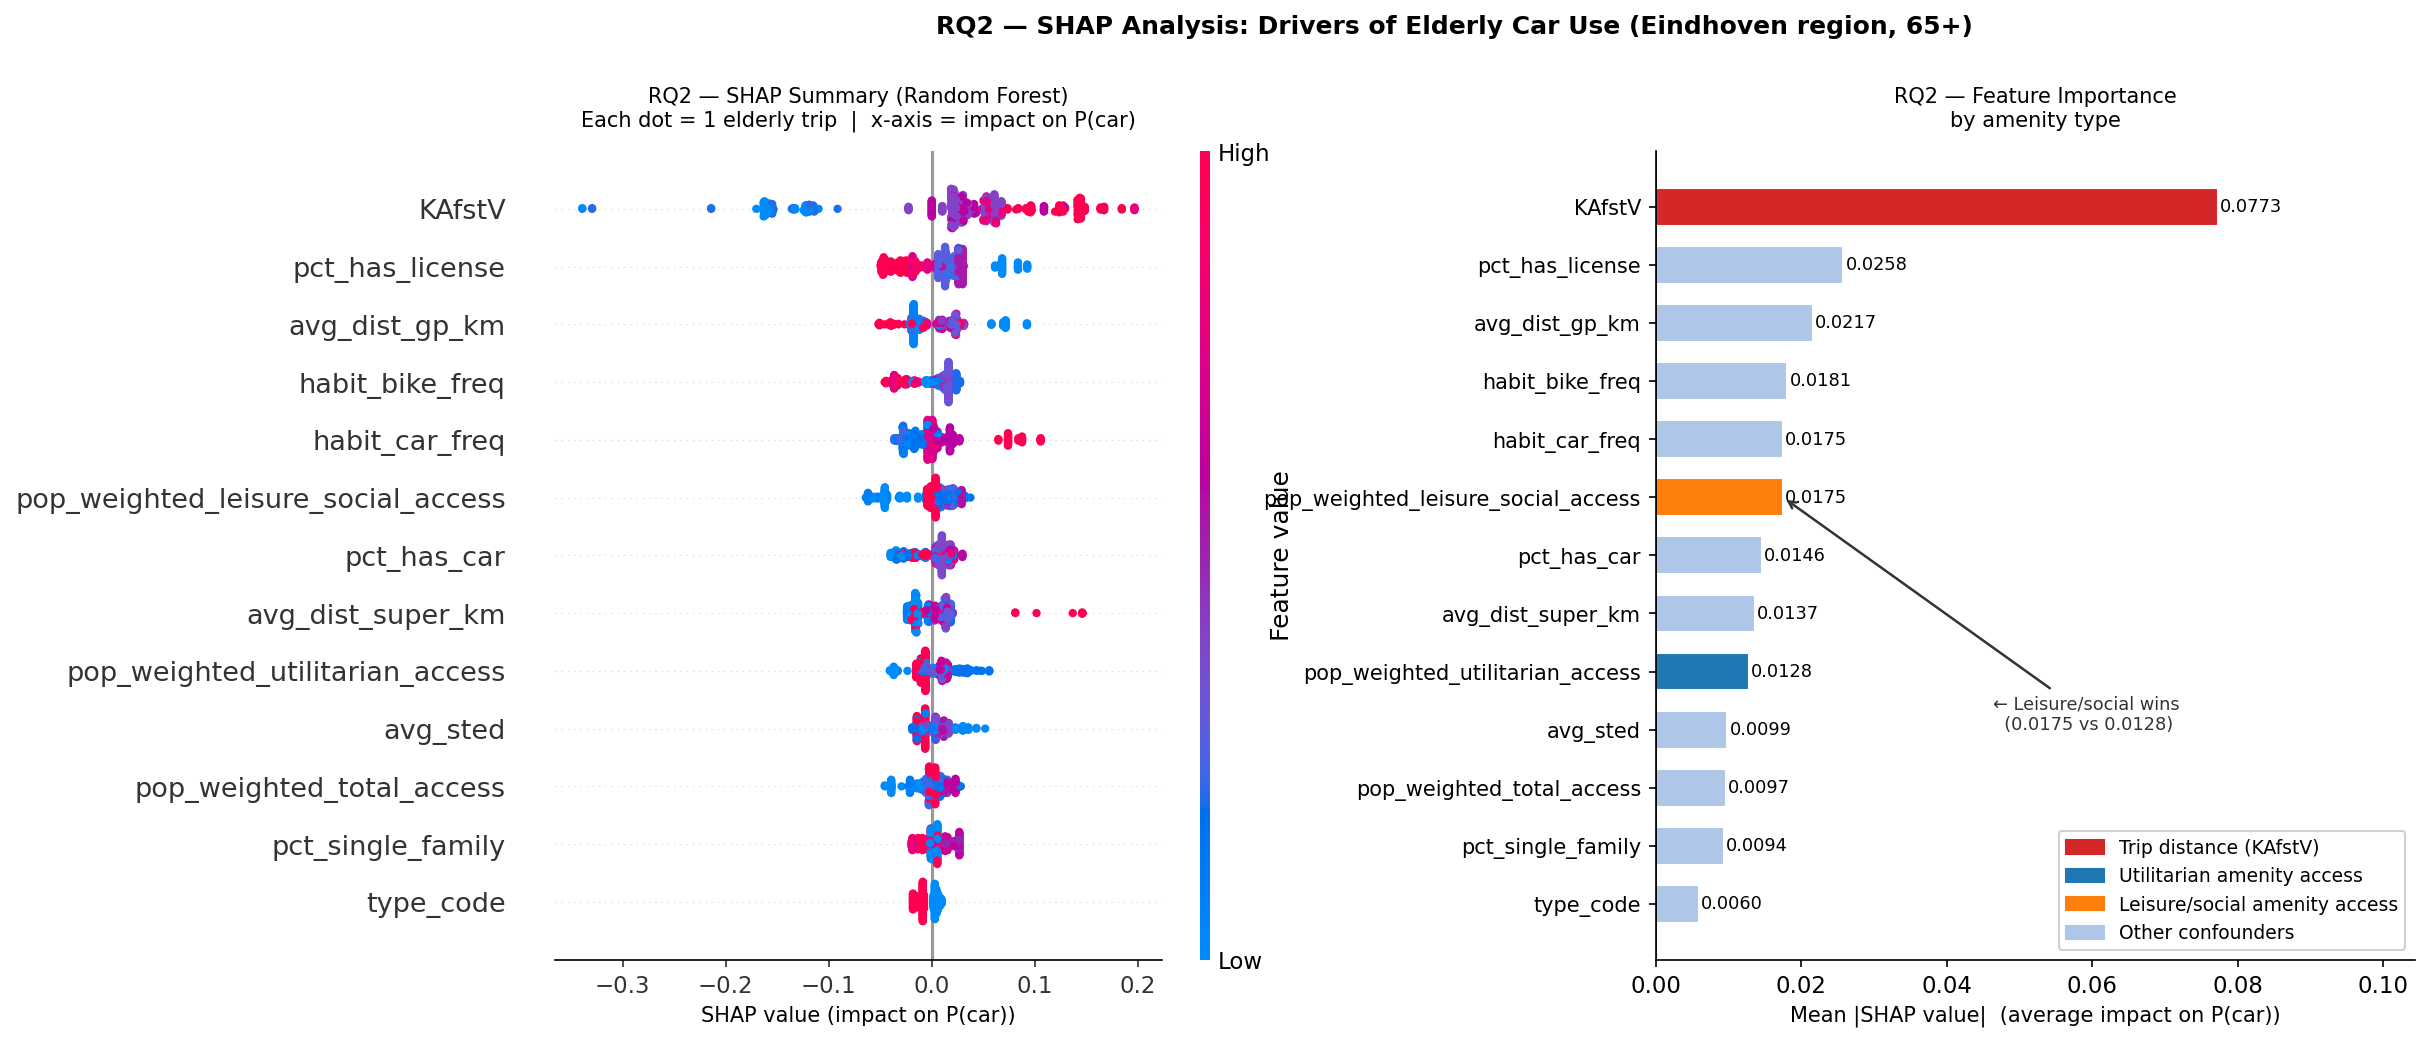


RQ2 KEY FINDING:
  |SHAP| utilitarian access    : 0.01281
  |SHAP| leisure/social access : 0.01749
  → LEISURE/SOCIAL amenities are a STRONGER predictor of elderly car use


In [56]:
# ── SHAP Summary + Feature Importance (leisure vs utilitarian) ────────────────
shap_mean_rf2 = pd.Series(
    np.abs(sv2).mean(axis=0), index=FEAT_COLS_RQ2
).sort_values(ascending=False)

def feat_color2(f):
    if "utilitarian" in f: return "#1f77b4"
    if "leisure"     in f: return "#ff7f0e"
    if f == "KAfstV":      return "#d62728"
    return "#aec7e8"

# Normalise for display only
scaler2      = StandardScaler()
X2_sample_sc = pd.DataFrame(scaler2.fit_transform(X2_sample), columns=FEAT_COLS_RQ2)

fig = plt.figure(figsize=(16, 7))
gs  = fig.add_gridspec(1, 2, wspace=0.45)
ax_shap = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])

# ── Left: SHAP summary ────────────────────────────────────────────────────────
plt.sca(ax_shap)
shap.summary_plot(sv2, X2_sample_sc, feature_names=FEAT_COLS_RQ2,
                  show=False, max_display=13, plot_size=None)
ax_shap.set_title("RQ2 — SHAP Summary (Random Forest)\n"
                  "Each dot = 1 elderly trip  |  x-axis = impact on P(car)",
                  fontsize=10, pad=12)
ax_shap.set_xlabel("SHAP value (impact on P(car))", fontsize=10)

# ── Right: bar chart, sorted descending ──────────────────────────────────────
sorted_feats  = shap_mean_rf2.sort_values(ascending=True)   # ascending for barh
bar_colors2   = [feat_color2(f) for f in sorted_feats.index]
bars = ax_bar.barh(range(len(sorted_feats)), sorted_feats.values,
                   color=bar_colors2, edgecolor="white", height=0.65)

# Value labels
for i, (val, feat) in enumerate(zip(sorted_feats.values, sorted_feats.index)):
    ax_bar.text(val + 0.0003, i, f"{val:.4f}", va="center", fontsize=8.5)

ax_bar.set_yticks(range(len(sorted_feats)))
ax_bar.set_yticklabels(sorted_feats.index, fontsize=10)
ax_bar.set_xlabel("Mean |SHAP value|  (average impact on P(car))", fontsize=10)
ax_bar.set_title("RQ2 — Feature Importance\nby amenity type", fontsize=10, pad=12)
ax_bar.set_xlim(0, sorted_feats.max() * 1.35)

# Vertical reference line at 0
ax_bar.axvline(0, color="black", lw=0.8)

# Highlight the two hypothesis features with annotation
util_val = shap_mean_rf2.get("pop_weighted_utilitarian_access", 0)
leis_val = shap_mean_rf2.get("pop_weighted_leisure_social_access", 0)
winner   = "Leisure/social" if leis_val > util_val else "Utilitarian"
ax_bar.annotate(f"← {winner} wins\n  ({leis_val:.4f} vs {util_val:.4f})",
                xy=(max(util_val, leis_val), sorted_feats.index.tolist().index(
                    "pop_weighted_leisure_social_access" if leis_val > util_val
                    else "pop_weighted_utilitarian_access")),
                xytext=(sorted_feats.max() * 0.6, 3),
                fontsize=8.5, color="#333333",
                arrowprops=dict(arrowstyle="->", color="#333333", lw=1.2))

from matplotlib.patches import Patch
ax_bar.legend(handles=[
    Patch(color="#d62728", label="Trip distance (KAfstV)"),
    Patch(color="#1f77b4", label="Utilitarian amenity access"),
    Patch(color="#ff7f0e", label="Leisure/social amenity access"),
    Patch(color="#aec7e8", label="Other confounders"),
], fontsize=9, loc="lower right", framealpha=0.9)

plt.suptitle("RQ2 — SHAP Analysis: Drivers of Elderly Car Use (Eindhoven region, 65+)",
             fontsize=12, y=1.01, fontweight="bold")
plt.savefig(OUT / "fig_t2_rq2_03_shap_util_vs_leisure.png", dpi=150, bbox_inches="tight")
plt.show()

util_shap = shap_mean_rf2.get("pop_weighted_utilitarian_access", np.nan)
leis_shap = shap_mean_rf2.get("pop_weighted_leisure_social_access", np.nan)
stronger  = "LEISURE/SOCIAL" if leis_shap > util_shap else "UTILITARIAN"
print(f"\nRQ2 KEY FINDING:")
print(f"  |SHAP| utilitarian access    : {util_shap:.5f}")
print(f"  |SHAP| leisure/social access : {leis_shap:.5f}")
print(f"  → {stronger} amenities are a STRONGER predictor of elderly car use")

## 10. SAVE MODELS FOR DASHBOARD

In [57]:
import joblib

# ── Save all trained models ───────────────────────────────────────────────────

# RQ1 models
joblib.dump(lr1,       MODEL_OUT / "rq1_logistic_regression.joblib")
joblib.dump(rf1_best,  MODEL_OUT / "rq1_random_forest.joblib")
joblib.dump(gb1_best,  MODEL_OUT / "rq1_xgboost.joblib")

# RQ2 models
joblib.dump(lr2,       MODEL_OUT / "rq2_logistic_regression.joblib")
joblib.dump(rf2_best,  MODEL_OUT / "rq2_random_forest.joblib")
joblib.dump(gb2_best,  MODEL_OUT / "rq2_xgboost.joblib")

# Also save the imputers (needed to preprocess new data!)
joblib.dump(imp1,      MODEL_OUT / "rq1_imputer.joblib")
joblib.dump(imp2,      MODEL_OUT / "rq2_imputer.joblib")

print("✓ All models saved to", MODEL_OUT)

✓ All models saved to c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\output_topic2\models


In [58]:
# ── Save the feature lists for both RQ1 and RQ2 ────────────────────────────────

print("RQ1 features:", FEAT_COLS_RQ1)
print("\nRQ2 features:", FEAT_COLS_RQ2)

with open(MODEL_OUT / "feature_lists.txt", "w") as f:
    f.write("=== RQ1 features ({} total) ===\n".format(len(FEAT_COLS_RQ1)))
    for i, feat in enumerate(FEAT_COLS_RQ1, 1):
        f.write(f"  {i:02d}. {feat}\n")
    f.write("\n=== RQ2 features ({} total) ===\n".format(len(FEAT_COLS_RQ2)))
    for i, feat in enumerate(FEAT_COLS_RQ2, 1):
        f.write(f"  {i:02d}. {feat}\n")

print("✓ Feature lists saved to", MODEL_OUT / "feature_lists.txt")

RQ1 features: ['pop_weighted_total_access', 'pop_weighted_utilitarian_access', 'pop_weighted_leisure_social_access', 'type_code', 'avg_sted', 'KAfstV', 'life_stage_code', 'pct_has_car', 'pct_has_license', 'pct_has_ebike', 'habit_bike_freq', 'habit_car_freq', 'avg_dist_gp_km', 'avg_dist_super_km', 'pct_single_family', 'pct_cycling_season', 'pct_weekend', 'ls_Family w/ Kids', 'ls_Mid-life No Kids (30-54)', 'ls_Older Adult (55-69)', 'ls_Senior (70+)', 'ls_Young Adult (18-29)']

RQ2 features: ['pop_weighted_utilitarian_access', 'pop_weighted_leisure_social_access', 'pop_weighted_total_access', 'KAfstV', 'type_code', 'avg_sted', 'pct_has_car', 'pct_has_license', 'habit_car_freq', 'habit_bike_freq', 'avg_dist_gp_km', 'avg_dist_super_km', 'pct_single_family']
✓ Feature lists saved to c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\output_topic2\models\feature_lists.txt
